# Load embedding data

In [18]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np

sc.settings.set_figure_params(dpi=150, dpi_save=300,facecolor='white')

z_data = pd.read_csv("./data_GSE204684_developing_human_cerebral_cortex/joint_mu.csv")
obs_info = np.arange(z_data.shape[0])
var_info = np.arange(z_data.shape[1])
ann_data = sc.read_h5ad("./data_hvg5000.h5ad")
z_adata = ad.AnnData(X=z_data, obs=ann_data.obs)

In [19]:
len(set(ann_data.obs['author_cell_type']))

15

# Clustering

/home/ywniu/anaconda3/envs/diffusionEnv/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


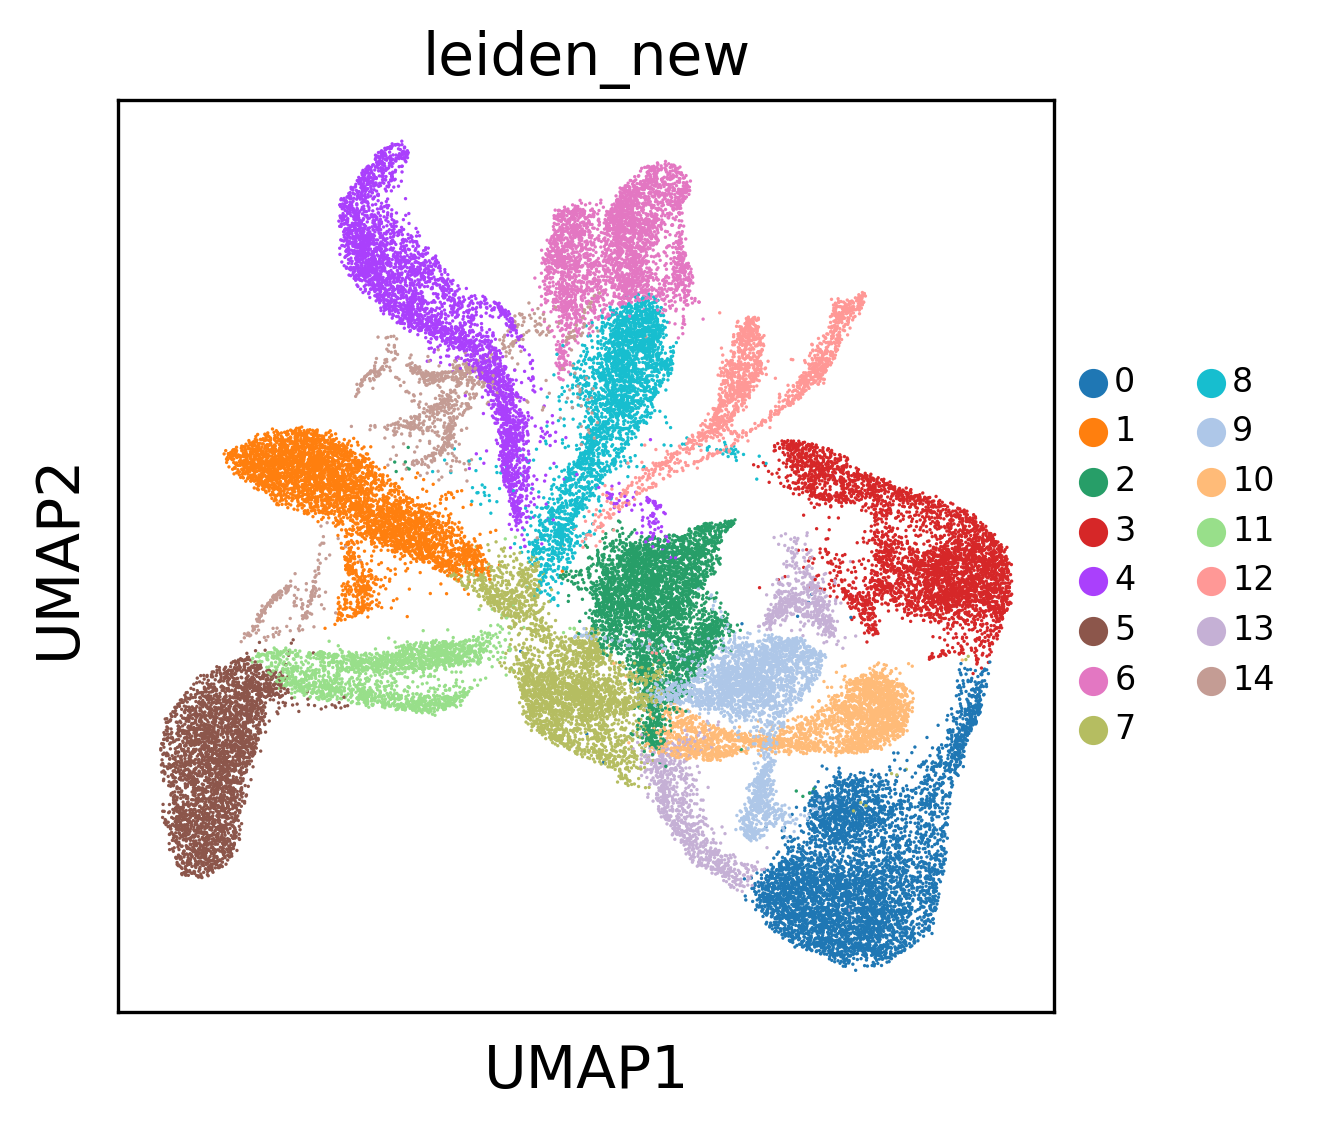

/home/ywniu/anaconda3/envs/diffusionEnv/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


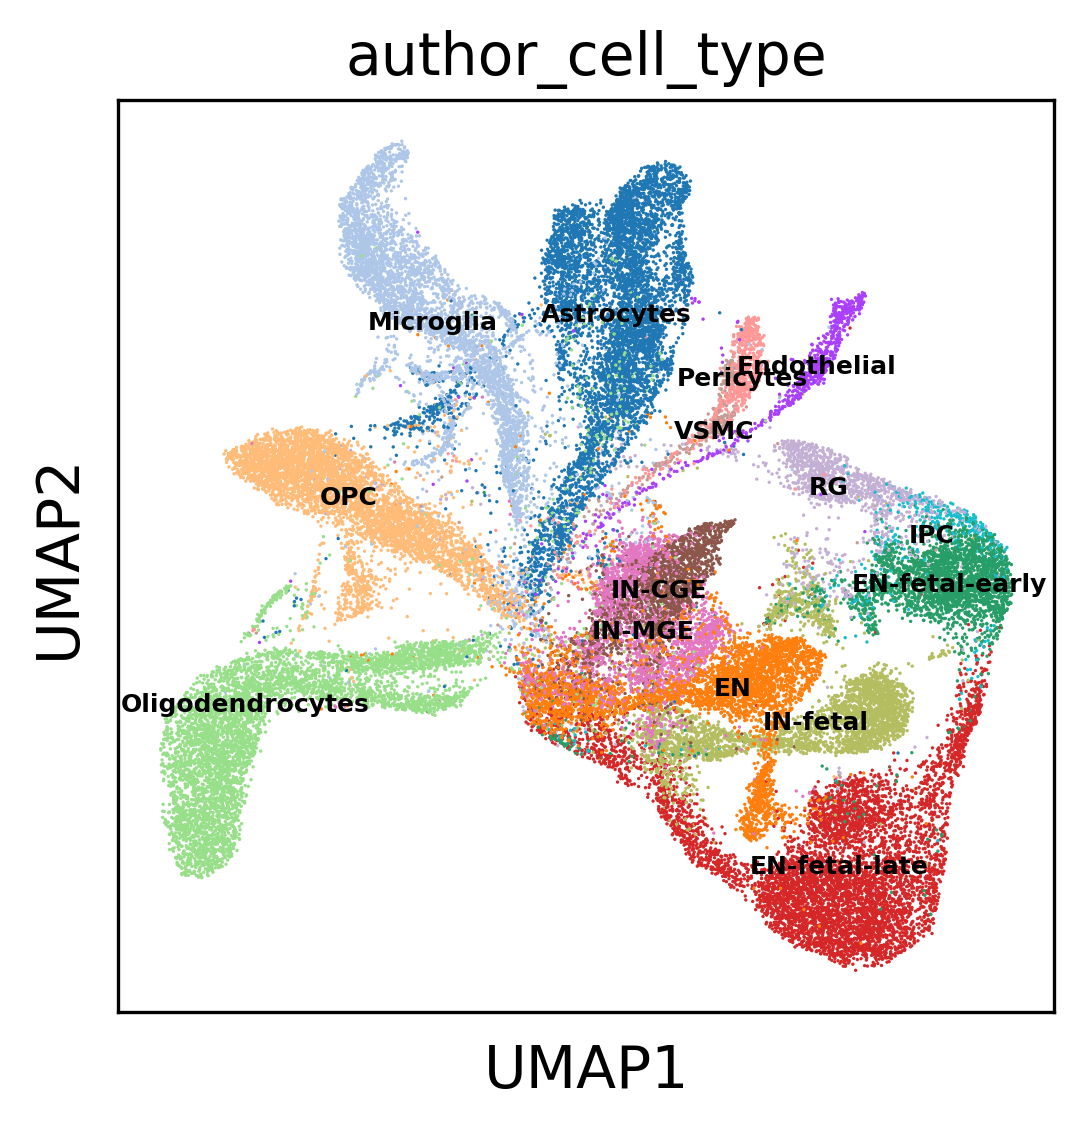

In [20]:
sc.pp.neighbors(z_adata,n_neighbors=20,use_rep='X')#,use_rep='X' ,n_neighbors=30
sc.tl.leiden(z_adata,key_added='leiden_new',resolution=0.3)#,resolution=0.5,
sc.tl.umap(z_adata)#,min_dist=0.2
sc.pl.umap(z_adata,color=['leiden_new'],legend_fontsize=8)#legend_loc='on data',
sc.pl.umap(z_adata, color=['author_cell_type'],legend_loc='on data',legend_fontsize=6)#,save='_mu_ondata.png'

# Clustering metric calculation

In [21]:
from sklearn import metrics
labels_true = z_adata.obs["author_cell_type"]
labels_pred = z_adata.obs["leiden_new"]
#print(labels_true.isnull().sum())  
#print(labels_pred.isnull().sum())  
#labels_true = labels_true.cat.add_categories(['unknown'])
#labels_true.fillna('unknown', inplace=True)
print('ARI: ', metrics.adjusted_rand_score(labels_true, labels_pred))
print('MI: ', metrics.mutual_info_score(labels_true, labels_pred))
print('AMI: ', metrics.adjusted_mutual_info_score(labels_true,labels_pred))
print('NMI: ',metrics.normalized_mutual_info_score(labels_true,labels_pred))
print('homogeneity: ',metrics.homogeneity_score(labels_true, labels_pred))
print('completeness: ',metrics.completeness_score(labels_true, labels_pred))
print('v_score: ',metrics.v_measure_score(labels_true, labels_pred))

ARI:  0.6489297875905107
MI:  1.9003178088884318
AMI:  0.747699290658081
NMI:  0.7479135241035524
homogeneity:  0.7760056831855435
completeness:  0.7217842341163532
v_score:  0.7479135241035524
